## De-coupled UTCI (*geo3DopenSim*)

[**Trafalgar Park**](https://www.capetown.gov.za/Family%20and%20home/see-all-city-facilities/our-recreational-facilities/District%20parks/Trafalgar-Park), Woodstock, Cape Town, South Africa 

Educational-scale **Pedstrian Wind Comfort (PWC)** and **Universal Thermal Comfort Indictor (UTCI)** with [**OpenFOAM**](https://www.openfoam.com).

Unlike the ***geo3D*** [urbanFlow.ipynb](https://github.com/AdrianKriger/geo3D/blob/main/suburb/urbanFlow-noInternet.ipynb), which executes an [OpenFoam]() simulation with buildings only, this workflow uses a 3D model with a 'real-world' ground surface and dedicated regions: terrain, roads, recreation (parks, etc), including buildings.

The location of the trees and their metrics (height, type, group) | used in the [OpenFoam CFD](https://www.openfoam.com) | are a product of local knowledge. i.e.: NO scientific  basis. I walked around the site and consulted [Google](https://en.wikipedia.org/wiki/Google).

**about the site:** [**Trafalgar Park**](https://www.capetown.gov.za/Family%20and%20home/see-all-city-facilities/our-recreational-facilities/District%20parks/Trafalgar-Park) contains The French Redoubt (more formally the Central Redoubt). A small military fortification built by the French in the 1781 when France briefly occupied and defended the Cape during the wars of the revolutionary era. The site is a Provincial Heritage Site (1999) and records its original declaration as a National Monument in September 1968 - [**SAHRIS**](https://www.sahris.org.za/node/38387)

In [1]:
#load the magic

%matplotlib inline
import os
import sys

import time
import datetime
from datetime import timedelta
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import geopandas as gpd
import json
import geojson

from shapely.geometry import Polygon, Point, shape, mapping

import pyproj

from cjio import cityjson

import utci

import matplotlib.pyplot as plt

In [2]:
# With the new 0.10.x syntax:
with open('25m-ws3Dtbsrp.json', 'r') as f:
    cm = cityjson.reader(f)

In [3]:
print(cm)

CityJSON version = 2.0.0
EPSG = 32734
bbox = [ 262442.097 6241611.786 -14.540 264943.544 6244113.233 121.630 ]
Extensions = ['Energy']
=== CityObjects ===
|-- TINRelief (1)
|-- Road (57)
|-- Building (305)
    |-- BuildingInstallation (1)
        |-- +Energy-PVSystem (1)
|-- LandUse (7)
|-- SolitaryVegetationObject (43)
materials = False
textures = False


In [4]:
#- harvest the buildings, roads, recreations spaces (parks, etc)  and trees from the CityJSON
data = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # CityJSON types are singular: 'Building' or 'BuildingPart'
    if obj_data['type'] in ['Building', 'BuildingPart']:
        # Establish a fresh dictionary for this specific row
        row = {'id': obj_id}
        
        # Safely pull attributes if they exist
        row.update(obj_data.get('attributes', {}))
        
        data.append(row)

df = pd.DataFrame(data) 

dataR = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # CityJSON types are singular: 'Building' or 'BuildingPart'
    if obj_data['type'] in ['Road']:
        # Establish a fresh dictionary for this specific row
        row = {'id': obj_id}
        
        # Safely pull attributes if they exist
        row.update(obj_data.get('attributes', {}))
        
        dataR.append(row)

Rdf = pd.DataFrame(dataR) 

dataT = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # CityJSON types are singular: 'Building' or 'BuildingPart'
    if obj_data['type'] in ['SolitaryVegetationObject']:
        # Establish a fresh dictionary for this specific row
        row = {'id': obj_id}
        
        # Safely pull attributes if they exist
        row.update(obj_data.get('attributes', {}))
        
        dataT.append(row)

Tdf = pd.DataFrame(dataT)

dataL = []
for obj_id, obj_data in cm.j['CityObjects'].items():
    # CityJSON types are singular: 'Building' or 'BuildingPart'
    if obj_data['type'] in ['LandUse']:
        # Establish a fresh dictionary for this specific row
        row = {'id': obj_id}
        
        # Safely pull attributes if they exist
        row.update(obj_data.get('attributes', {}))
        
        dataL.append(row)

Ldf = pd.DataFrame(dataL)

#- blds
df.head(2)

,id,osm_id,address,building,building:levels,operator,building_height,roof_height,ground_height,plus_code,footprint,building:flats,amenity,beds,social_facility,building:use,residential
0,osm_13501234,13501234,The Woodstock Exchange 66-68 Albert Road Woods...,commercial,6.0,Signatura,18.1,23.44,5.34,4FRW3CFW+69W,"[[[263928.922, 6243053.284], [263890.36, 62430...",NaN,NaN,NaN,NaN,NaN,NaN
1,osm_65768975,65768975,Woodstock Station Woodstock Cape Town,train_station,3.0,NaN,9.7,13.99,4.29,4FRW3CFW+PFM,"[[[263906.88, 6243153.778], [263907.77, 624314...",NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#- roads
Rdf.head(2)

,id,osm_id,highway,name,surface,lanes,width,footprint,oneway
0,osm_752043705,752043705,primary,Albert Road,asphalt,2.0,4.4,"[[[263770.564632, 6243077.326827], [263772.870...",NaN
1,osm_8025893,8025893,residential,Alexander Street,asphalt,2.0,4.4,"[[[263846.635437, 6243122.325903], [263848.708...",NaN


In [6]:
#- trees
Tdf.head(2)

,id,height,width,group,type,footprint,ground_height
0,1,2.1,0.16,standard,broadleaf,"[263524.82531, 6242753.341395]",17.25
1,2,2.1,0.18,standard,broadleaf,"[263493.33702, 6242569.210221]",28.87


In [7]:
#- recreation spaces
Ldf.head(2)

,id,osm_id,leisure,name,footprint,surface
0,osm_32441919,32441919,park,Trafalgar Park,"[[[263579.100069, 6242873.159705], [263576.806...",NaN
1,osm_899596274,899596274,park,Sussex Street Park,"[[[264003.370928, 6243045.181298], [264009.713...",NaN


In [8]:
#- harvest the crs
theinfo = cm.get_info()
crs = theinfo[1]

# account for holes
def coords_to_polygon(rings):
    if not rings or len(rings) == 0:
        return None
    outer = rings[0]
    # Only pass holes if they actually exist in the list
    holes = rings[1:] if len(rings) > 1 else []
    return Polygon(shell=outer, holes=holes)

# Convert JSON string to Python list
#df['footprint_coords_list'] = df['footprint'].apply(json.loads)
# Only apply json.loads if the entry is actually a string
df['footprint_coords_list'] = df['footprint'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

#- now gdf: blds
geometry = df['footprint_coords_list'].apply(coords_to_polygon)
Bgdf = gpd.GeoDataFrame(df, geometry=geometry)
#gdf['geometry'] = gdf['footprint_coords_list'].apply(coords_to_polygon)
Bgdf.crs = crs[7:]
# Drop columns inplace
Bgdf.drop(columns=['footprint', 'footprint_coords_list'], inplace=True)
Bgdf.head(2)

,id,osm_id,address,building,building:levels,operator,building_height,roof_height,ground_height,plus_code,building:flats,amenity,beds,social_facility,building:use,residential,geometry
0,osm_13501234,13501234,The Woodstock Exchange 66-68 Albert Road Woods...,commercial,6.0,Signatura,18.1,23.44,5.34,4FRW3CFW+69W,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((263928.922 6243053.284, 263890.360 6..."
1,osm_65768975,65768975,Woodstock Station Woodstock Cape Town,train_station,3.0,NaN,9.7,13.99,4.29,4FRW3CFW+PFM,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((263906.880 6243153.778, 263907.770 6..."


In [9]:
#- now gdf: roads

Rdf['footprint_coords_list'] = Rdf['footprint'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

geometry = Rdf['footprint_coords_list'].apply(coords_to_polygon)
Rgdf = gpd.GeoDataFrame(Rdf, geometry=geometry)
#gdf['geometry'] = gdf['footprint_coords_list'].apply(coords_to_polygon)
Rgdf.crs = crs[7:]
# Drop columns inplace
Rgdf.drop(columns=['footprint', 'footprint_coords_list'], inplace=True)
Rgdf.head(2)

,id,osm_id,highway,name,surface,lanes,width,oneway,geometry
0,osm_752043705,752043705,primary,Albert Road,asphalt,2.0,4.4,NaN,"POLYGON ((263770.565 6243077.327, 263772.871 6..."
1,osm_8025893,8025893,residential,Alexander Street,asphalt,2.0,4.4,NaN,"POLYGON ((263846.635 6243122.326, 263848.709 6..."


In [10]:
#- now gdf: trees

Tdf['footprint_coords_list'] = Tdf['footprint'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

def coords_to_point(coords):
    if coords is None:
        return None

    return Point(coords[0], coords[1])

geometry = Tdf['footprint_coords_list'].apply(coords_to_point)
Tgdf = gpd.GeoDataFrame(Tdf, geometry=geometry)
#gdf['geometry'] = gdf['footprint_coords_list'].apply(coords_to_polygon)
Tgdf.crs = crs[7:]
# Drop columns inplace
Tgdf.drop(columns=['footprint', 'footprint_coords_list'], inplace=True)
Tgdf.head(2)

,id,height,width,group,type,ground_height,geometry
0,1,2.1,0.16,standard,broadleaf,17.25,POINT (263524.825 6242753.341)
1,2,2.1,0.18,standard,broadleaf,28.87,POINT (263493.337 6242569.210)


In [11]:
#- now gdf: recreation

Ldf['footprint_coords_list'] = Ldf['footprint'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

geometry = Ldf['footprint_coords_list'].apply(coords_to_polygon)
Lgdf = gpd.GeoDataFrame(Ldf, geometry=geometry)
#gdf['geometry'] = gdf['footprint_coords_list'].apply(coords_to_polygon)
Lgdf.crs = crs[7:]
# Drop columns inplace
Lgdf.drop(columns=['footprint', 'footprint_coords_list'], inplace=True)
Lgdf.head(2)

,id,osm_id,leisure,name,surface,geometry
0,osm_32441919,32441919,park,Trafalgar Park,NaN,"POLYGON ((263579.100 6242873.160, 263576.806 6..."
1,osm_899596274,899596274,park,Sussex Street Park,NaN,"POLYGON ((264003.371 6243045.181, 264009.713 6..."


In [12]:
#gdf.head(2)
bbox = theinfo[2]
extent = [float(bbox[9:18]), float(bbox[20:30]), float(bbox[39:48]), float(bbox[50:60])]

# Calculate center values from your extent
center_x = (extent[0] + extent[2]) / 2
center_y = (extent[1] + extent[3]) / 2

extent

[262442.09, 6241611.78, 264943.5, 6244113.2]

In [13]:
#center_x

In [14]:
Su_inlet = 6.9      # wind speed: m/s
Su_deg = 210        # wind direction

In [15]:
#- harvest the openFoam post-process result. wind profile at 1.5m above terrain surface
#start = time.time()

#case_path = './result/openfoam/wStockDecoupledUTCI/summer/'

summerPed_df  = utci.load_openfoam_vtk('pedestrianZone.vtk', wind_deg=Su_deg, extent=extent, radius=400.0)

#end = time.time()
#print('runtime:', str(timedelta(seconds=(end - start))))

summerPed_df.head(3)

,X,Y,Z,U,V,u_mag,k
0,264067.778467,6.242738e+06,15.684100,0.367021,0.743827,0.830119,0.579509
1,264075.555291,6.242752e+06,15.179050,0.341695,0.775941,0.848431,0.563629
2,264045.799980,6.242735e+06,16.087467,0.170467,0.246186,0.299521,0.576932


In [16]:
len(summerPed_df)

26840

### Plot

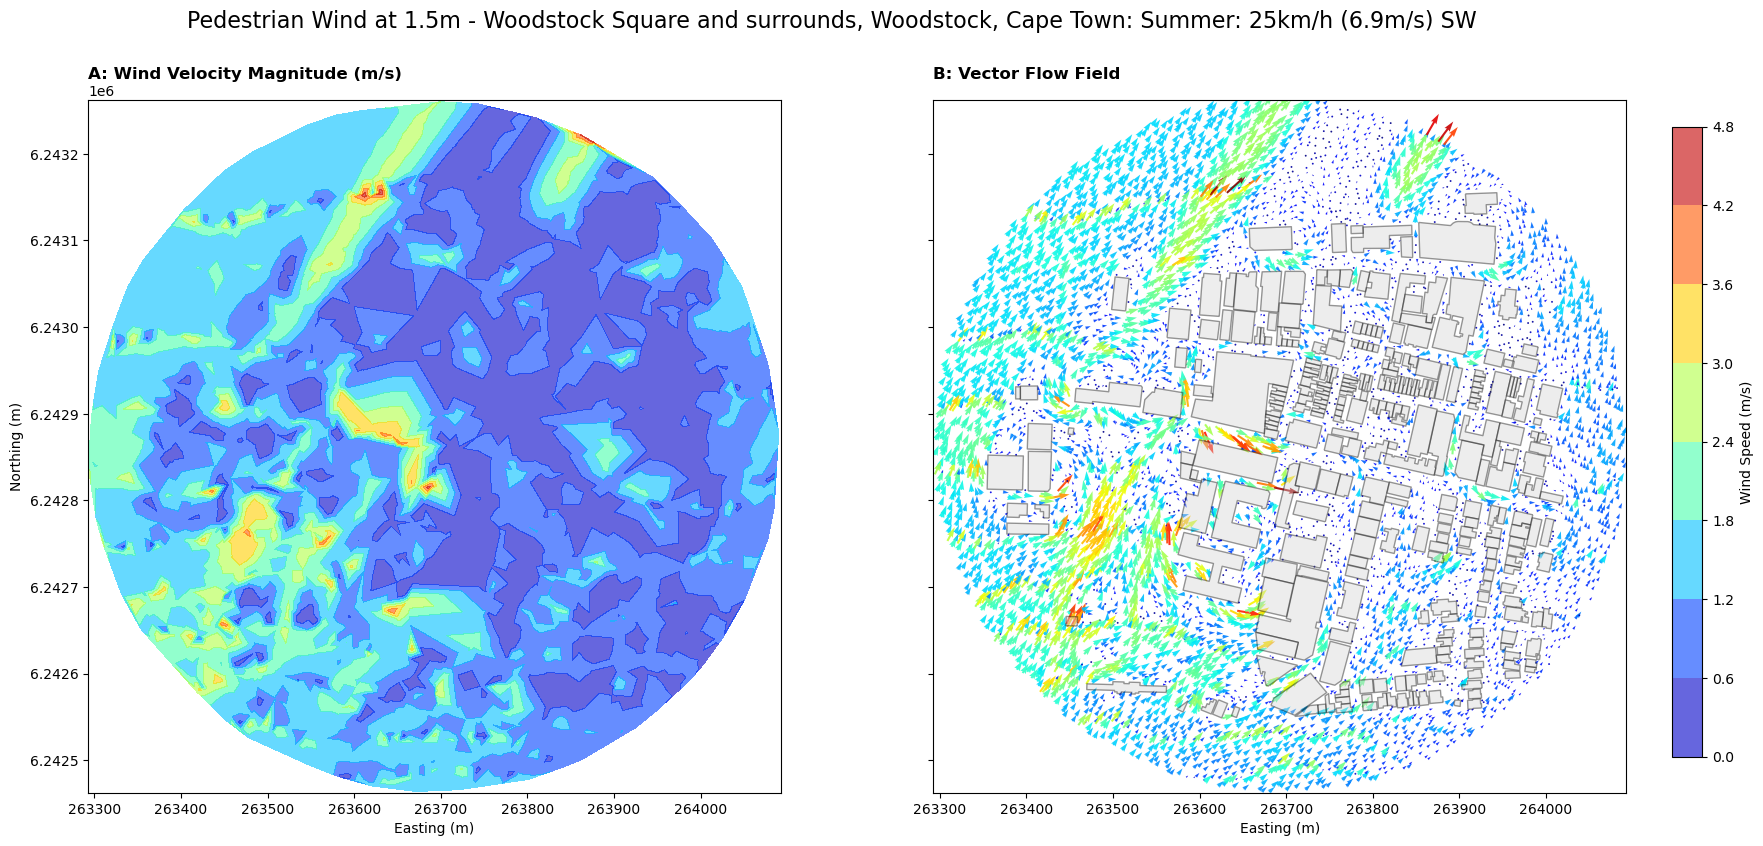

In [30]:
fig, axes =  utci.plot_wind_analysis(summerPed_df, Bgdf, center_x, center_y, radius=400, 
                                title_suffix="Woodstock Square and surrounds, Woodstock, Cape Town: Summer: 25km/h (6.9m/s) SW")

plt.show()

**we can compare with the result of the [urbanFlow.ipynb](https://github.com/AdrianKriger/geo3D/blob/main/suburb/urbanFlow-noInternet.ipynb) for this specific  community**: `wStock.param`

**NOTICE:** how uniform the vector field from the [urbanFlow](https://github.com/AdrianKriger/geo3D/blob/main/suburb/urbanFlow-noInternet.ipynb) result (below) is; compared to the current result (above). We can see how the ground -- which slopes downward as we go North -- and the different regions on the surface of the mesh (terrain, roads, recreation) influence the wind speed.

![ws.png](../docs/wStockNOterrain.jpg)

**we can zoom into Trafalgar Park**; to understand how the trees affects the pedestrian wind profile.

The trees are the concentric brown circles.

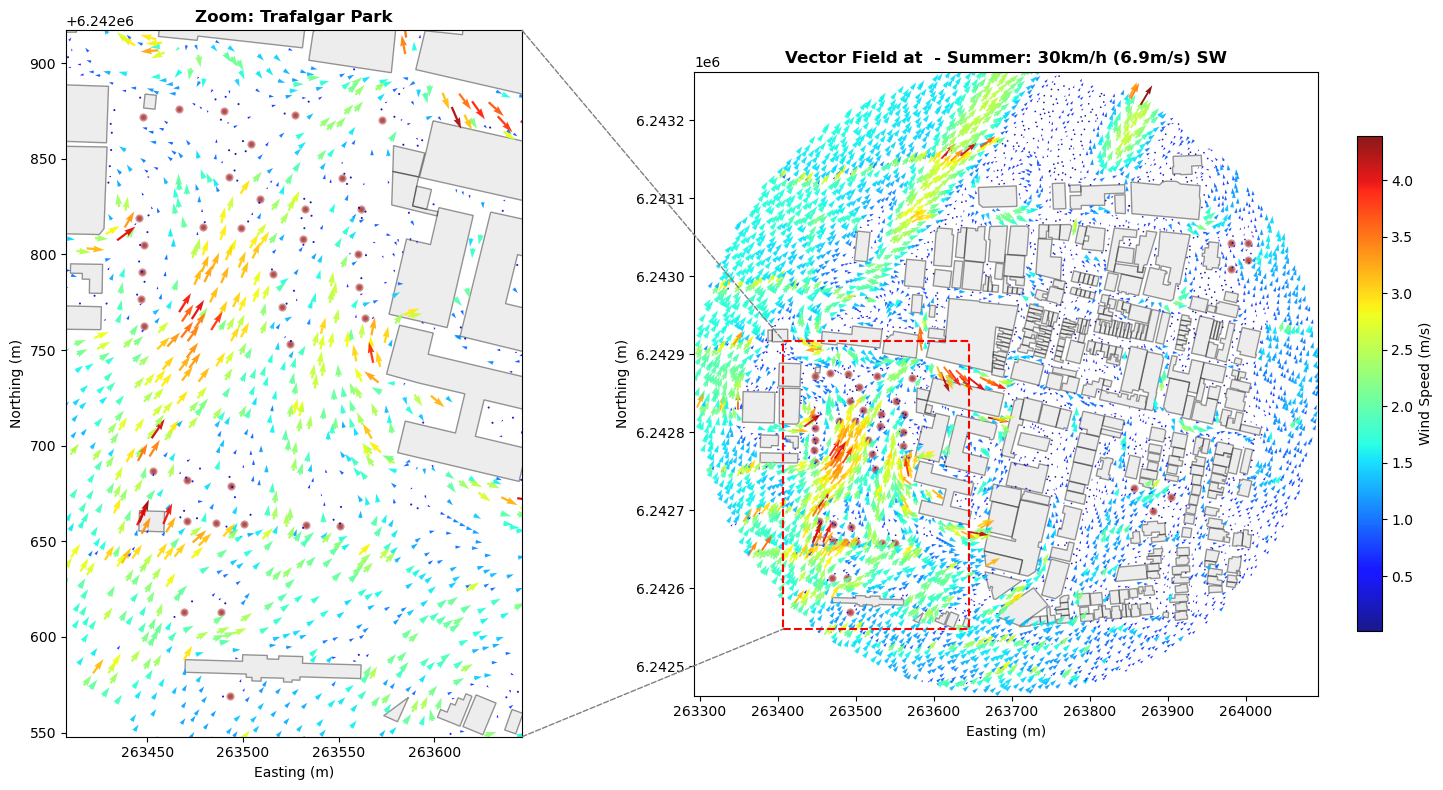

In [18]:
# Execution
fig, ax =  utci.plot_wind_vectors(summerPed_df, Bgdf, Lgdf, Tgdf, center_x, center_y, radius=400, title_suffix="Summer: 30km/h (6.9m/s) SW")

plt.show()

we can see how the down-sloping terrain, the change in surface roughness (terrain to road to recreation) and the trees all contribute to the tightly bound-core as the wind funnels through the park. Notice too how the clustering of trees is the north acts as a highly porous but restrictive barrier. 

The [OpenFOAM CFD](https://www.openfoam.com) simulation understands these are porous zones. Unlike the buildings which **deflect** momentum; the leaves and branches **sap** momentum.

## UTCI

In [19]:
def calculate_utci_robust(ta, mrt, v, rh):
    """
    Standard UTCI calculation based on the multi-node human heat balance model.
    ta: Air Temperature (°C)
    tr: Mean Radiant Temperature (°C)
    v: Wind speed at 10m height (m/s)
    rh: Relative Humidity (%)
    """
    # Offset from air temperature
    dtp = mrt - ta
    
    # Fundamental UTCI equation constants (Approximation)
    # This captures the non-linear interaction of wind and radiation
    utci = ta + (0.344 * dtp) + (0.000185 * ta * dtp) - (0.013 * v * dtp) - \
           (0.007 * (v**2)) + (0.012 * rh) - (0.0004 * ta * rh)
           
    return round(utci, 2)

In [20]:
#- scale pedestrian wind profile (1.5m) to 10m

#- these are the values from the openFOAM simulation
Z0_MAP = {
    "water": 0.0002,
    "airport_runway": 0.0024,
    "open": 0.03,
    "agri_sheltered": 0.1,
    "rural": 0.2,
    "village, town and suburb": 0.4,
    "urban suburb and city": 0.8,
    "metro": 1.2
}

# 1. Define your domain's aerodynamic roughness length (z0)
# This should match your boundary conditions (e.g., from your z0 lookup or ABL conditions)
z0_urban = 0.8  # meters (example for urban suburb and city)

# 2. Dynamically calculate the reduction ratio based on your exact inlet law
# Sampling z at 1.5m (pedestrian zone) and 10m (reference height)
z_pedestrian = 1.5
z_reference = 10.0

r_dynamic = np.log((z_pedestrian + z0_urban) / z0_urban) / np.log((z_reference + z0_urban) / z0_urban)

print(f"Dynamically calculated ratio (r) for z0={z0_urban}m: {r_dynamic:.4f}")
# For z0 = 0.8m, r is roughly 0.404 rather than the standard open-country 0.68!


# Back-calculate the equivalent open-field U10 for the UTCI empirical script
summerPed_df['U10_equivalent'] = summerPed_df['u_mag'] / r_dynamic

# 4. Now pass df_summer['U10_equivalent'] into your UTCI thermal comfort function

Dynamically calculated ratio (r) for z0=0.8m: 0.4058


In [21]:
#- look
summerPed_df.head(2)

,X,Y,Z,U,V,u_mag,k,U10_equivalent
0,264067.778467,6.242738e+06,15.68410,0.367021,0.743827,0.830119,0.579509,2.045866
1,264075.555291,6.242752e+06,15.17905,0.341695,0.775941,0.848431,0.563629,2.090996


In [22]:
#- summer
#- temp.     ~ durham: summer 27, winter 14 | wQuarter: summer 28, winter 16 | mamre: summer 26, winter 17
#- rel. hum. ~ durham: summer 50, winter 80 | wQuarter: summer 40, winter 83 | mamre: summer 70, winter 77

Sta = 28.0
Srh = 40.0

In [23]:
#- the date and time of the UTCI evaluation

# Example for ..., Jan 29th at 14:00 (Summer Heat)
dt_summer = datetime.datetime(2025, 1, 29, 14, 0, tzinfo=ZoneInfo("Africa/Johannesburg"))

In [24]:
#- where is the sun at this time and date?

transformer = pyproj.Transformer.from_crs(f"""epsg:{crs[7:]}""", "epsg:4326", always_xy=True)

# 4. Perform the coordinate transformation
center_lon, center_lat = transformer.transform(center_x, center_y)

sun_azimuth, sun_altitude= utci.get_sun_position(center_lat, center_lon, dt_summer)

print('Azimuth:', sun_azimuth)
print('Altitude:', sun_altitude)

Azimuth: 279.5438591041635
Altitude: 46.949421246479645


In [25]:
#- calculate if a person is standing in the shadows or direct sunlight

shadows = utci.calculate_shadows(Bgdf, Tgdf, sun_azimuth, sun_altitude)

In [26]:
#- now we add the solar radiation, at this time of the year, for this community.

# Load the NASA.csv file, skipping the metadata header
file_path = 'POWER_Regional_Monthly_1984_2025.csv'

# Load the NASA POWER dataset
df = pd.read_csv(file_path, skiprows=9)

# Clean column names
df.columns = [c.strip() for c in df.columns]

# Find the closest NASA grid point in the file
closest_lat = min(df['LAT'].unique(), key=lambda x: abs(x - center_lat))
closest_lon = min(df['LON'].unique(), key=lambda x: abs(x - center_lon))

# Filter for that location and remove missing data (-999)
site_df = df[(df['LAT'] == closest_lat) & (df['LON'] == closest_lon)].copy()
site_df = site_df[site_df['JAN'] != -999]

# Calculate the multi-year (long term: 1984-2025) average
ghi_jan = site_df['JAN'].mean()
#ghi_jul = site_df['JUL'].mean()

#print(f"Coordinates matched to NASA grid: {closest_lat}, {closest_lon}")
print(f"January Average GHI: {ghi_jan:.3f} kWh/m²/day")
#print(f"July Average GHI:    {ghi_jul:.3f} kWh/m²/day")

January Average GHI: 8.341 kWh/m²/day


In [27]:
#- calculate Mean Radiant Temperature (MRT). represents the sum of all radiation hitting a person.

def get_mrt_offset(daily_ghi_kwh):
    """
    Rough conversion from daily average GHI to peak MRT offset degrees.
    Based on typical solar geometry and human absorption.
    """
    # 1 kWh/m2/day daily avg is roughly 2.6 degrees of peak MRT offset
    return round(daily_ghi_kwh * 2.6, 1)

mrt_offset = get_mrt_offset(ghi_jan)
print('Mean Radiant Temperature Offset:', mrt_offset)

Mean Radiant Temperature Offset: 21.7


In [28]:
# Build the utci layer correctly — shade first, then slice, then UTCI

summerPed_df = utci.build_utci_layer(summerPed_df, shadows, ta=Sta, rh=Srh)

#- UTCI at ground level, using 10m wind
def _utci_row(row):
    mrt = Sta + mrt_offset if not row['is_shaded'] else Sta
    return calculate_utci_robust(Sta, mrt, row['u_mag_10m'], Srh)

summerPed_df['utci'] = summerPed_df.apply(_utci_row, axis=1)

summerPed_df.head(2)

,X,Y,Z,U,V,u_mag,k,U10_equivalent,is_shaded,u_mag_10m,utci
0,264067.778467,6.242738e+06,15.68410,0.367021,0.743827,0.830119,0.579509,2.045866,False,2.045866,35.00
1,264075.555291,6.242752e+06,15.17905,0.341695,0.775941,0.848431,0.563629,2.090996,False,2.090996,34.99


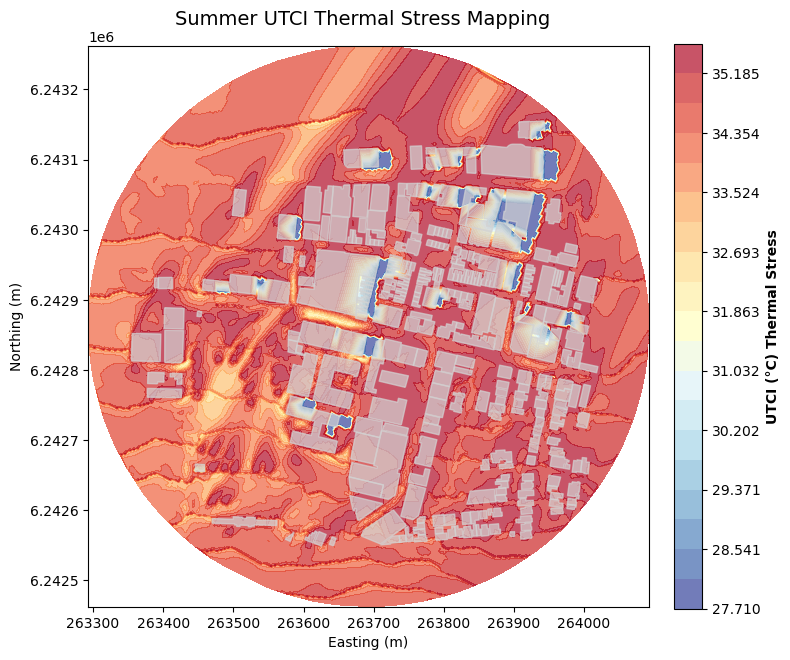

In [29]:
# --- Execution ---
fig, ax =  utci.plot_utci_summer(summerPed_df, Bgdf, Tgdf, center_x, center_y, radius=400, title_suffix=" ")

plt.show()

**again:** have a look at how a ground surface with regions (terrain, roads, recreation) and the trees influence the result. 

You can clearly see the sweeping contour bands crawling across the background where the UTCI values spike. The elevation changes | its a course [25m elevation](https://ngi.dlrrd.gov.za/index.php/what-we-do/maps-and-geospatial-information/40-elevation-data) | forces the wind velocity to drop, driving up the thermal stress. When the air is moving (wind) the UTCI settles to a lower value.

Notice too the higher UTCI values in Trafalgar Park coincide with the location of the trees. This might seem counter intuitive but its a factor of how we calculate UTCI. The wind plays the major role and the thermodynamic benefits of vegetation are NOT accounted for. [Evapotranspiration](https://en.wikipedia.org/wiki/Evapotranspiration) pumps moisture into the air and does lower the temperature... I'll look into it.